In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import warnings
warnings.filterwarnings('ignore')

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["LANGCHAIN_VERBOSE"] = "false"

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["COHERE_API_KEY"] = os.getenv("COHERE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_cohere import CohereEmbeddings
from langchain_groq import ChatGroq
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader

In [3]:
# read text files from data folder
import os

os.getcwd()
data_folder = os.path.join(os.getcwd(), '..', 'data')
documents = []
for filename in os.listdir(data_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(data_folder, filename)
        loader = TextLoader(file_path)
        documents.extend(loader.load())

In [4]:
len(documents)

2

In [5]:
cohere_embeddings = CohereEmbeddings(model="embed-english-light-v3.0")

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=30)
split_docs = splitter.split_documents(documents)
len(split_docs)

32

In [7]:
vectorstore = FAISS.from_documents(split_docs, cohere_embeddings)

In [8]:
customer_it_support_db = vectorstore.save_local("customer_it_support_db")

In [9]:
customer_it_support_db = FAISS.load_local("customer_it_support_db",cohere_embeddings,allow_dangerous_deserialization=True)

In [10]:
customer_it_support_db_retriever = customer_it_support_db.as_retriever(search_type="mmr",search_kwargs={"fetch_k": 3})

In [11]:
results = customer_it_support_db_retriever.invoke("what is Authentication and login?")

In [12]:
results

[Document(id='582be08c-0e26-4fea-ab84-df82bda6a9c4', metadata={'source': 'e:\\Agents\\test_rag\\..\\data\\documentation.txt'}, page_content='Issue: Unable to login Steps: 1. Reset password via portal 2. Check CAPS\nLOCK 3. Ensure VPN connection (remote users) 4. Verify account is active'),
 Document(id='6259316d-14dc-42c1-b89c-60e06709dcf7', metadata={'source': 'e:\\Agents\\test_rag\\..\\data\\documentation.txt'}, page_content='-----------------------------------\n  SECTION 1: LOGIN & AUTHENTICATION\n  -----------------------------------'),
 Document(id='fce51902-a224-4778-984b-b638878a3aab', metadata={'source': 'e:\\Agents\\test_rag\\..\\data\\documentation.txt'}, page_content='-   Mandatory 2FA\n-   Do not share credentials\n-   Report phishing emails\n-   Regular password updates')]

In [13]:
# Read PDF file for Film Making
from langchain_community.document_loaders import PyMuPDFLoader
file_path = "E:\Agents\data\Short-History-of-Film-Making.pdf"
loader = PyMuPDFLoader(file_path)
documents = loader.load()

In [14]:
film_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=60)
film_split_docs = film_splitter.split_documents(documents)
len(film_split_docs)

37

In [15]:
cohere_embeddings = CohereEmbeddings(model="embed-english-light-v3.0")

In [16]:
film_vectorstore = FAISS.from_documents(film_split_docs, cohere_embeddings)

In [17]:
film_vectorstore = film_vectorstore.save_local("film_db")

In [18]:
film_vectorstore = FAISS.load_local("film_db",cohere_embeddings,allow_dangerous_deserialization=True)

In [19]:
film_vectorstore_retriver_db =film_vectorstore.as_retriever(search_type="mmr",search_kwargs={"fetch_k": 5})
#film_response[0].page_content

In [20]:
# Read PDF file for Film Making
from langchain_community.document_loaders import PyMuPDFLoader
claimate_path= r"E:\Agents\data\Understanding_Climate_Change.pdf"
loader = PyMuPDFLoader(claimate_path)
documents = loader.load()

claimate_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=60)
claimate_split_docs = claimate_splitter.split_documents(documents)
len(claimate_split_docs)

171

In [21]:
claimate_vectorstore = FAISS.from_documents(claimate_split_docs, cohere_embeddings)
claimate_vectorstore = claimate_vectorstore.save_local("claimate_db")

In [22]:
claimate_vectorstore = FAISS.load_local("claimate_db",cohere_embeddings,allow_dangerous_deserialization=True)

In [23]:
claimate_vectorstore_db =claimate_vectorstore.as_retriever(search_type="mmr",search_kwargs={"fetch_k": 5})
#claimate_vectorstore_db[0].page_content

In [24]:
# Using Tavily Search Results tool to search the web for latest information

from langchain_community.tools.tavily_search import TavilySearchResults
tavily_tool = TavilySearchResults(max_results=3)

C:\Users\Venkatesh\AppData\Local\Temp\ipykernel_22944\3186409922.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=3)


In [25]:
tavily_tool.invoke("What is the current weather in Hyderabad in india?")

[{'title': 'Hyderabad\xa030 days weather forecast,\xa0Hyderabad\xa0weather forecast | QWeather',
  'url': 'https://www.qweather.com/en/weather30d/hyderabad-E54B8.html',
  'content': "Telangana - India   2026-04-18   Saturday   17.37N, 78.47E\n\n# Hyderabad\n\n# Hyderabad\n\nIn the next 30 days, there will be no rain or snow, 30 days' Temp above 35°, the Max Temp is 42°(26-Apr) and the Min Temp is 24°(20-Apr).\n\nSun\n\nMon\n\nTue\n\nWed\n\nThu\n\nFri\n\nSat\n\nQWeather\n\n40°~26°\n\nQWeather\n\n39°~26°\n\nQWeather\n\n39°~24°\n\nQWeather\n\n37°~25°\n\nQWeather\n\n37°~26°\n\nQWeather\n\n38°~26°\n\nQWeather\n\n39°~25°\n\nQWeather\n\n41°~26°\n\nQWeather\n\n42°~26°\n\nQWeather\n\n39°~25°\n\nQWeather\n\n39°~25°\n\nQWeather\n\n39°~26°\n\nQWeather\n\n40°~27°\n\nQWeather\n\n40°~27°\n\nQWeather\n\n41°~28°\n\nQWeather\n\n41°~27°\n\nQWeather\n\n40°~29°\n\nQWeather\n\n41°~29°\n\nQWeather\n\n41°~27°\n\nQWeather\n\n41°~28°\n\nQWeather\n\n40°~29°\n\nQWeather\n\n41°~28°\n\nQWeather\n\n41°~29°\n\nQWeath

In [26]:
# Converting Retriever to Retriever Tools
from langchain_classic.tools.retriever import create_retriever_tool

customer_it_support_db_retriever_tool = create_retriever_tool(
    retriever=customer_it_support_db_retriever,
    name="customer_it_support_db_retriever",
    description="Use this tool to search the customer IT support database for information about products, IT services, or issues."
)

film_making_db_retriever_tool = create_retriever_tool(
    retriever=film_vectorstore_retriver_db,
    name="film_making_db_retriever",
    description="Use this tool to search the film making database for information about the history of film"
    
)
claimate_change_db_retriever_tool = create_retriever_tool(
    retriever=claimate_vectorstore_db,   
    name="claimate_change_db_retriever",
    description="Use this tool to search the claimate change database for information about the claimate change"
)

In [27]:
claimate_change_db_retriever_tool

StructuredTool(name='claimate_change_db_retriever', description='Use this tool to search the claimate change database for information about the claimate change', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001F99D8F0C20>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001F99D8F0AE0>)

In [28]:
# Combine / Binding all tools with LLM
llm = ChatGroq(model="qwen/qwen3-32b")
tools = [customer_it_support_db_retriever_tool, film_making_db_retriever_tool, claimate_change_db_retriever_tool, tavily_tool]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F99E547590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F99E579FA0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'customer_it_support_db_retriever', 'description': 'Use this tool to search the customer IT support database for information about products, IT services, or issues.', 'parameters': {'properties': {'query': {'description': 'query to look up in retriever', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'funct

# LangGraph Workflow

In [29]:
from typing import List, Dict, Any,Annotated,Sequence,Literal
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage,SystemMessage
from langgraph.graph.message import add_messages

In [30]:
class AgentState(TypedDict):
    # adding messages to the agent state to keep track of the conversation history
    # add_messages is a function that will be used to add messages to the agent state
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [31]:
# Intialize the ChatGroq LLM
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")

In [32]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current conversation state.

    The agent can decide whether to:
    - Use available tools (retriever, Tavily, etc.)
    - Or respond directly if no tool is needed

    Args:
        state (dict): Contains the current conversation state, including:
            - "messages": List of previous messages

    Returns:
        dict: Updated state with the new agent response appended to messages
    """

    print("----- CALL AGENT -----")

    messages = state["messages"]

    system_prompt = SystemMessage(
        content=(
            "You are an intelligent assistant with access to tools.\n\n"
            "Rules:\n"
            "- Use the retriever for internal knowledge questions\n"
            "- Use Tavily for external or latest information\n"
            "- If you already know the answer, respond directly\n"
            "- Be concise and accurate"
        )
    )

    input_messages = [system_prompt] + messages

    response = llm_with_tools.invoke(input_messages)

    # Check if the response contains tool calls
    if hasattr(response, 'tool_calls') and response.tool_calls:
        tool_names = [tool_call['name'] for tool_call in response.tool_calls]
        print(f"🔧 Agent decided to use tools: {', '.join(tool_names)}")
    else:
        print("💬 Agent will respond directly (no tools needed)")

    return {"messages": messages + [response]}


In [33]:
from langchain_classic import hub
from langchain_core.messages import HumanMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from pydantic import BaseModel, Field

In [34]:
# Grade the documents retrieved by the retriever tool


### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3-32b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [35]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="qwen/qwen3-32b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [36]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen/qwen3-32b")
    response = model.invoke(msg)
    return {"messages": [response]}

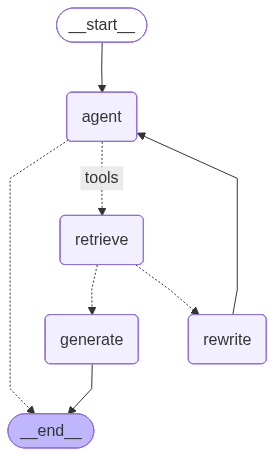

In [ ]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([customer_it_support_db_retriever_tool, film_making_db_retriever_tool, claimate_change_db_retriever_tool,tavily_tool], name="retrieve")
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node("generate", generate)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges("agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [38]:
from langchain_core.messages import HumanMessage

graph.invoke({
    "messages": [HumanMessage(content="unable to login to my account?")]
})

----- CALL AGENT -----


🔧 Agent decided to use tools: customer_it_support_db_retriever
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='unable to login to my account?', additional_kwargs={}, response_metadata={}, id='ab343af7-2f26-4ecb-ad7c-a3d5150c7a02'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is having trouble logging into their account. Let me figure out which tool to use here. The available tools are the customer IT support database, film making database, claimate change database, and Tavily search.\n\nSince the issue is about account login, that\'s probably an IT support issue. The customer_it_support_db_retriever is designed for product, IT service, or issue lookups. So I should use that. The query parameter would be "unable to login to my account". I don\'t need to use Tavily here because it\'s an internal IT issue, not a current event or external info. Let me check the other databases—film making and claimate change don\'t seem relevant. So the correct tool is customer_it_support_db_retriever with the user\'s query as the argument.\n',

In [39]:
result = graph.invoke({
    "messages": [HumanMessage(content="what are the extream wether conditions caused by claimate change?")]
})

# Extract tool usage information
messages = result["messages"]
tool_calls_found = []

for msg in messages:
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        for tool_call in msg.tool_calls:
            tool_calls_found.append(tool_call['name'])

# Print tool usage and response
if tool_calls_found:
    print(f"🔧 Tools used: {', '.join(set(tool_calls_found))}")
else:
    print("💬 No tools were called")

print("Agent Response:")
print(result["messages"][-1].content)

----- CALL AGENT -----
🔧 Agent decided to use tools: claimate_change_db_retriever
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---
🔧 Tools used: claimate_change_db_retriever
Agent Response:
<think>
Okay, the user is asking about extreme weather conditions caused by climate change. Let me look at the context provided.

The context mentions extreme weather events like hurricanes, heatwaves, droughts, and heavy rainfall. It also talks about how warmer ocean temperatures intensify hurricanes and typhoons, leading to more destructive storms and flooding in coastal areas. There's a section on heatwaves becoming more frequent and severe, especially in cities due to the urban heat island effect. Other effects include changing seasons impacting ecosystems and human activities.

So the answer should list the extreme weather events mentioned: hurricanes, heatwaves, droughts, heavy rainfall. Also, mention the intensified hurricanes due to warmer oceans and the impact on coastal r

In [40]:
# Function to run agent and display response
def run_agent_and_display(query):
    """Run the agent with a query and display the response"""
    result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })

    # Extract tool usage information
    messages = result["messages"]
    tool_calls_found = []

    for msg in messages:
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tool_call in msg.tool_calls:
                tool_calls_found.append(tool_call['name'])

    # Get the final message (agent's response)
    final_message = result["messages"][-1]

    print(f"Query: {query}")
    if tool_calls_found:
        print(f"🔧 Tools used: {', '.join(set(tool_calls_found))}")
    else:
        print("💬 No tools were called")
    print(f"Response: {final_message.content}")
    print("-" * 50)

    return final_message.content

# Example usage
response = run_agent_and_display("What is climate change?")

----- CALL AGENT -----
🔧 Agent decided to use tools: claimate_change_db_retriever
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---
Query: What is climate change?
🔧 Tools used: claimate_change_db_retriever
Response: <think>
Okay, the user is asking what climate change is. Let me check the provided context.

The context starts by defining climate change as significant, long-term changes in the global climate, involving weather patterns like temperature, precipitation, and wind. It mentions human activities, especially burning fossil fuels and deforestation, as major contributors over the past century. There's also info on extreme weather events and impacts on ecosystems.

I need to make sure I capture the key points: definition, causes, and effects. The user probably wants a concise answer without too much detail. Let me structure it in three sentences. First, the definition. Then the main causes. Finally, the effects like extreme weather and ecosystem impacts. Avoid me

In [41]:
# More detailed response handling
def get_agent_response(query):
    """Get agent response with detailed information"""
    result = graph.invoke({
        "messages": [HumanMessage(content=query)]
    })

    messages = result["messages"]

    # Extract tool usage information
    tool_calls_found = []
    for msg in messages:
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tool_call in msg.tool_calls:
                tool_calls_found.append(tool_call['name'])

    print(f"📝 Query: {query}")
    print(f"📊 Total messages in conversation: {len(messages)}")

    if tool_calls_found:
        print(f"🔧 Tools used: {', '.join(set(tool_calls_found))}")
    else:
        print("💬 No tools were called")

    # Show all messages in the conversation
    for i, msg in enumerate(messages):
        if hasattr(msg, 'type'):
            if msg.type == 'human':
                print(f"👤 Human: {msg.content}")
            elif msg.type == 'ai':
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    tool_names = [tc['name'] for tc in msg.tool_calls]
                    print(f"🤖 AI (calling tools: {', '.join(tool_names)}): {msg.content}")
                else:
                    print(f"🤖 AI: {msg.content}")
        else:
            # For other message types (like tool results)
            print(f"🔧 Tool/System: {str(msg)[:100]}...")

    print("-" * 50)

    # Return the final response
    return messages[-1].content

# Test with different queries
queries = [
    "unable to login to my account?",
    "What is the history of film making?"
]

for query in queries:
    response = get_agent_response(query)

----- CALL AGENT -----
🔧 Agent decided to use tools: customer_it_support_db_retriever
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---
📝 Query: unable to login to my account?
📊 Total messages in conversation: 4
🔧 Tools used: customer_it_support_db_retriever
👤 Human: unable to login to my account?
🤖 AI (calling tools: customer_it_support_db_retriever): 
👤 Human: <think>
Okay, the user is having trouble logging in. Let me look at the context provided. The steps listed are resetting password, checking CAPS LOCK, ensuring VPN connection for remote users, and verifying the account is active. Then there's a section on checking Active Directory sync and MFA status under Advanced, and a VPN issues section.

First, the user should try resetting their password through the portal. Then check if CAPS LOCK is on. If they're remote, making sure the VPN is connected is important. Also, confirming the account is active might be necessary. The advanced steps mention Active Directory s

In [ ]:
# Test a query that doesn't need tools
test_result = graph.invoke({
    "messages": [HumanMessage(content="Hello, how are you?")]
})

# Check tool usage
messages = test_result["messages"]
tool_calls_found = []

for msg in messages:
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        for tool_call in msg.tool_calls:
            tool_calls_found.append(tool_call['name'])

if tool_calls_found:
    print(f"🔧 Tools used: {', '.join(set(tool_calls_found))}")
else:
    print("💬 No tools were called")

print("Agent Response:")
print(test_result["messages"][-1].content)

----- CALL AGENT -----
💬 Agent will respond directly (no tools needed)
💬 No tools were called
Agent Response:
Hello! I'm here to help with any questions you might have. How can I assist you today?


Failed to refresh cache entry rlm/rag-prompt: Connection error caused failure to GET /commits/rlm/rag-prompt/latest in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /commits/rlm/rag-prompt/latest (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: None
API Key: 
